In [24]:
%pip install -U pandas numpy matplotlib scikit-learn ipykernel
import tf_idf_observer as tid
import matplotlib.pyplot as plt
import pandas as pd



In [25]:
import sys
print(sys.executable)

/opt/homebrew/opt/python@3.10/bin/python3.10


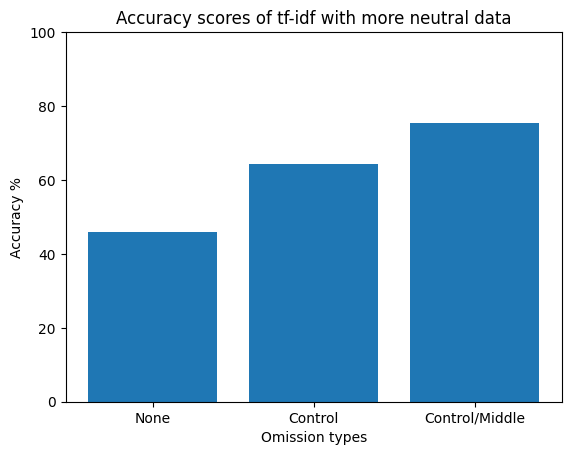

In [29]:
accuracy_all_neutral, confusion_matrix_all_neutral = tid.tf_idf_accuracy('datasets/dataset_a_neutral.csv', False, False)
accuracy_noctrl_neutral, confusion_matrix_noctrl_neutral = tid.tf_idf_accuracy('datasets/dataset_a_neutral.csv', True, False)
accuracy_noctrl_middle_neutral, confusion_matrix_noctrl_middle_neutral = tid.tf_idf_accuracy('datasets/dataset_a_neutral.csv', True, True)
tests = ["None", "Control", "Control/Middle"]
scores = [accuracy_all_neutral*100, accuracy_noctrl_neutral*100, accuracy_noctrl_middle_neutral*100]
plt.bar(tests, scores)
plt.title("Accuracy scores of tf-idf with more neutral data")
plt.xlabel("Omission types")
plt.ylabel("Accuracy %")
plt.ylim(0, 100)
plt.show()

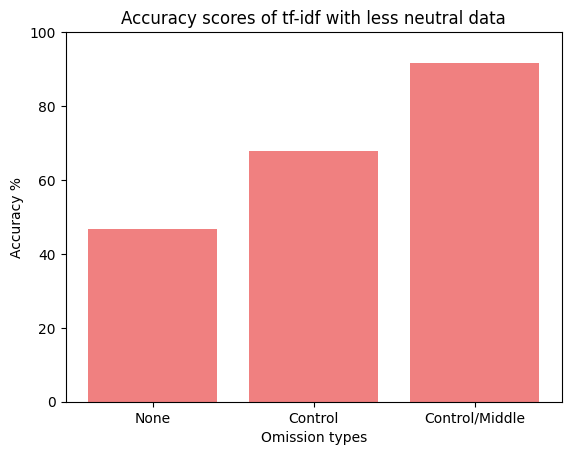

In [31]:
accuracy_all_bias, confusion_matrix_all_bias = tid.tf_idf_accuracy('datasets/dataset_b_biased.csv', False, False)
accuracy_noctrl_bias, confusion_matrix_noctrl_bias = tid.tf_idf_accuracy('datasets/dataset_b_biased.csv', True, False)
accuracy_noctrl_middle_bias, confusion_matrix_noctrl_middle_bias = tid.tf_idf_accuracy('datasets/dataset_b_biased.csv', True, True)
tests = ["None", "Control", "Control/Middle"]
scores = [accuracy_all_bias*100, accuracy_noctrl_bias*100, accuracy_noctrl_middle_bias*100]
plt.bar(tests, scores, color='lightcoral')
plt.title("Accuracy scores of tf-idf with less neutral data")
plt.xlabel("Omission types")
plt.ylabel("Accuracy %")
plt.ylim(0, 100)
plt.show()

In [35]:
llm_data_zshot = pd.read_csv('predictions/dataset_a_neutral_zero_shot_llm_observer.csv')
# llm_data_zshot = llm_data_zshot[llm_data_zshot['label'] != 0]
# llm_data_zshot = llm_data_zshot[llm_data_zshot['label'] != 2]

llm_labels_zshot = llm_data_zshot['label'].tolist()
llm_predictions_zshot = llm_data_zshot['prediction'].tolist()
correct_pred = 0

for i in range(len(llm_labels_zshot)):
    if(llm_labels_zshot[i] == llm_predictions_zshot[i]):
        correct_pred += 1

llm_accuracy_zshot = round(float(correct_pred)/float(len(llm_labels_zshot)), 4) * 100

print("LLM Accuracy: ", llm_accuracy_zshot, "%")


LLM Accuracy:  43.66 %


In [36]:
llm_data_fshot = pd.read_csv('predictions/dataset_a_neutral_few_shot_llm_observer.csv')
# llm_data_fshot = llm_data_fshot[llm_data_fshot['label'] != 0]
# llm_data_fshot = llm_data_fshot[llm_data_fshot['label'] != 2]

llm_labels_fshot = llm_data_fshot['label'].tolist()
llm_predictions_fshot = llm_data_fshot['prediction'].tolist()
correct_pred = 0

for i in range(len(llm_labels_fshot)):
    if(llm_labels_fshot[i] == llm_predictions_fshot[i]):
        correct_pred += 1

llm_accuracy_fshot = round(float(correct_pred)/float(len(llm_labels_fshot)), 4) * 100

print("LLM Accuracy: ", llm_accuracy_fshot, "%")


LLM Accuracy:  53.99 %


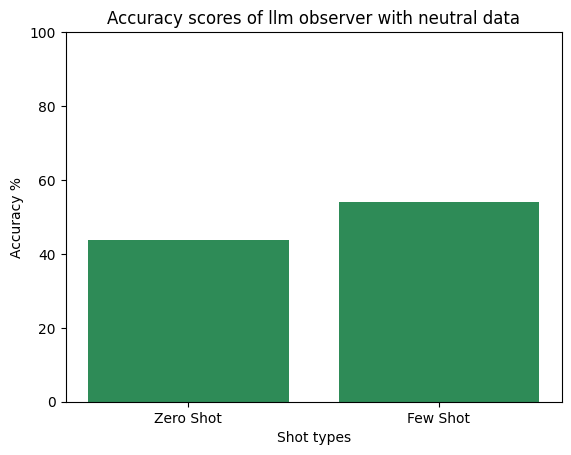

In [37]:
shots = ["Zero Shot", "Few Shot"]
llm_scores = [llm_accuracy_zshot, llm_accuracy_fshot]
plt.bar(shots, llm_scores, color="seagreen")
plt.title("Accuracy scores of llm observer with neutral data")
plt.xlabel("Shot types")
plt.ylabel("Accuracy %")
plt.ylim(0, 100)
plt.show()

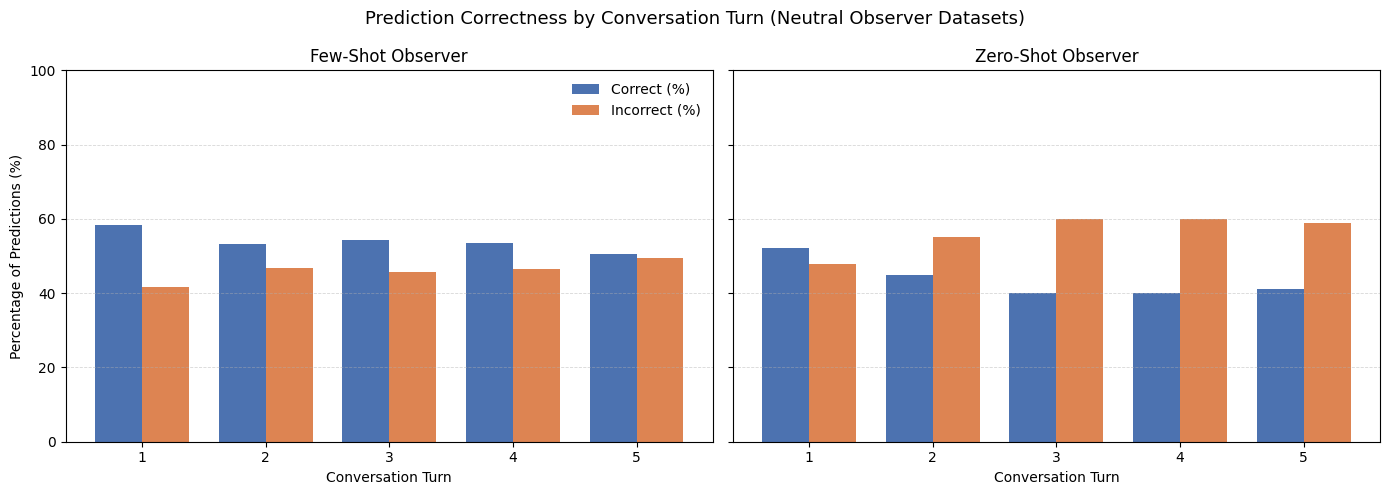

Few-shot per-turn summary:
   conversation_turn  total  correct  incorrect  correct_pct  incorrect_pct
0                  1    426      249        177        58.45          41.55
1                  2    426      227        199        53.29          46.71
2                  3    426      231        195        54.23          45.77
3                  4    426      228        198        53.52          46.48
4                  5    426      215        211        50.47          49.53

Zero-shot per-turn summary:
   conversation_turn  total  correct  incorrect  correct_pct  incorrect_pct
0                  1    426      222        204        52.11          47.89
1                  2    426      191        235        44.84          55.16
2                  3    426      171        255        40.14          59.86
3                  4    426      171        255        40.14          59.86
4                  5    426      175        251        41.08          58.92


In [38]:
# Per-turn prediction quality: grouped bar charts for few-shot vs zero-shot observer datasets
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

few_path = "predictions/dataset_a_neutral_few_shot_llm_observer.csv"
zero_path = "predictions/dataset_a_neutral_zero_shot_llm_observer.csv"

def per_turn_accuracy_breakdown(path):
    df = pd.read_csv(path)

    required_cols = {"conversation_turn", "label", "prediction"}
    missing = required_cols.difference(df.columns)
    if missing:
        raise ValueError(f"Missing required columns in {path}: {sorted(missing)}")

    grouped = (
        df.assign(is_correct=(df["label"] == df["prediction"]).astype(int))
          .groupby("conversation_turn", as_index=False)
          .agg(total=("is_correct", "size"), correct=("is_correct", "sum"))
          .sort_values("conversation_turn")
    )

    grouped["incorrect"] = grouped["total"] - grouped["correct"]
    grouped["correct_pct"] = (grouped["correct"] / grouped["total"]) * 100
    grouped["incorrect_pct"] = (grouped["incorrect"] / grouped["total"]) * 100

    return grouped

few_stats = per_turn_accuracy_breakdown(few_path)
zero_stats = per_turn_accuracy_breakdown(zero_path)

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
fig.suptitle("Prediction Correctness by Conversation Turn (Neutral Observer Datasets)", fontsize=13)

# Scientific/education-friendly tones
correct_color = "#4C72B0"   # muted blue
incorrect_color = "#DD8452" # muted orange

for ax, stats, title in [
    (axes[0], few_stats, "Few-Shot Observer"),
    (axes[1], zero_stats, "Zero-Shot Observer"),
]:
    turns = stats["conversation_turn"].to_numpy()
    x = np.arange(len(turns))
    width = 0.38

    ax.bar(x - width / 2, stats["correct_pct"], width, label="Correct (%)", color=correct_color)
    ax.bar(x + width / 2, stats["incorrect_pct"], width, label="Incorrect (%)", color=incorrect_color)

    ax.set_title(title)
    ax.set_xlabel("Conversation Turn")
    ax.set_xticks(x)
    ax.set_xticklabels(turns)
    ax.set_ylim(0, 100)
    ax.grid(axis="y", linestyle="--", linewidth=0.6, alpha=0.5)

axes[0].set_ylabel("Percentage of Predictions (%)")
axes[0].legend(frameon=False)

plt.tight_layout()
plt.show()

print("Few-shot per-turn summary:")
print(few_stats[["conversation_turn", "total", "correct", "incorrect", "correct_pct", "incorrect_pct"]].round(2))
print("\nZero-shot per-turn summary:")
print(zero_stats[["conversation_turn", "total", "correct", "incorrect", "correct_pct", "incorrect_pct"]].round(2))

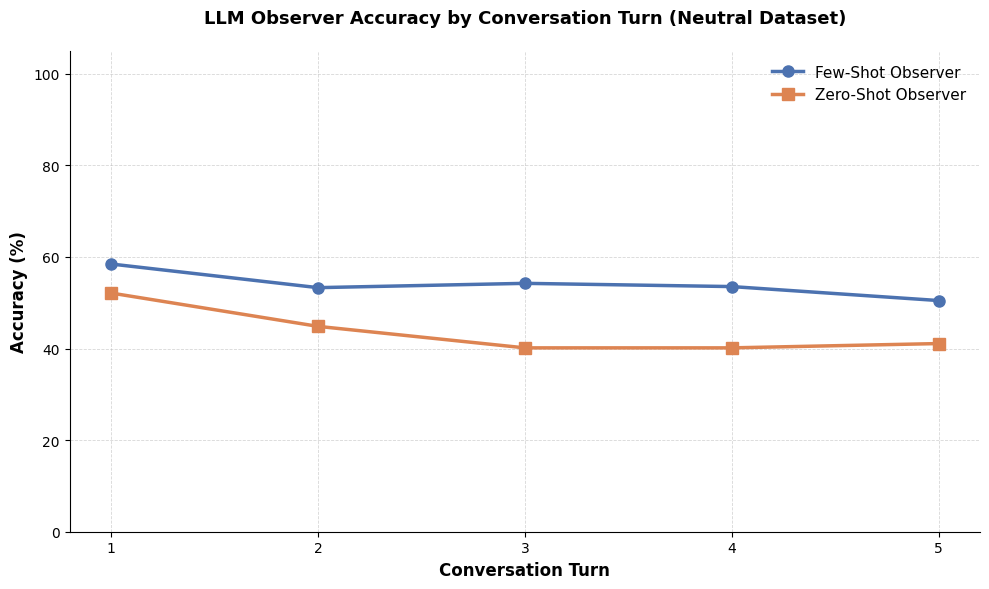

Accuracy Curve Summary (Neutral Dataset):

Few-Shot Observer:
  Mean Accuracy: 53.99%
  Min Accuracy: 50.47% (Turn 5)
  Max Accuracy: 58.45% (Turn 1)

Zero-Shot Observer:
  Mean Accuracy: 43.66%
  Min Accuracy: 40.14% (Turn 3)
  Max Accuracy: 52.11% (Turn 1)


In [39]:
# Accuracy curve: few-shot vs zero-shot across conversation turns
import numpy as np
import matplotlib.pyplot as plt

# Extract accuracy curves from per-turn data
few_turns = few_stats["conversation_turn"].values
few_accuracy = few_stats["correct_pct"].values

zero_turns = zero_stats["conversation_turn"].values
zero_accuracy = zero_stats["correct_pct"].values

# Create figure with scientific styling
fig, ax = plt.subplots(figsize=(10, 6))

# Plot lines with markers
few_line = ax.plot(few_turns, few_accuracy, marker='o', linewidth=2.5, markersize=8, 
                   label='Few-Shot Observer', color='#4C72B0')
zero_line = ax.plot(zero_turns, zero_accuracy, marker='s', linewidth=2.5, markersize=8, 
                    label='Zero-Shot Observer', color='#DD8452')

# Styling
ax.set_xlabel('Conversation Turn', fontsize=12, fontweight='bold')
ax.set_ylabel('Accuracy (%)', fontsize=12, fontweight='bold')
ax.set_title('LLM Observer Accuracy by Conversation Turn (Neutral Dataset)', 
             fontsize=13, fontweight='bold', pad=20)

ax.set_xticks(few_turns)
ax.set_ylim(0, 105)
ax.grid(True, linestyle='--', linewidth=0.6, alpha=0.5)
ax.legend(frameon=False, fontsize=11, loc='best')

# Remove top and right spines for cleaner look
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

# Print summary statistics
print("Accuracy Curve Summary (Neutral Dataset):")
print(f"\nFew-Shot Observer:")
print(f"  Mean Accuracy: {few_accuracy.mean():.2f}%")
print(f"  Min Accuracy: {few_accuracy.min():.2f}% (Turn {few_turns[few_accuracy.argmin()]})")
print(f"  Max Accuracy: {few_accuracy.max():.2f}% (Turn {few_turns[few_accuracy.argmax()]})")
print(f"\nZero-Shot Observer:")
print(f"  Mean Accuracy: {zero_accuracy.mean():.2f}%")
print(f"  Min Accuracy: {zero_accuracy.min():.2f}% (Turn {zero_turns[zero_accuracy.argmin()]})")
print(f"  Max Accuracy: {zero_accuracy.max():.2f}% (Turn {zero_turns[zero_accuracy.argmax()]})")

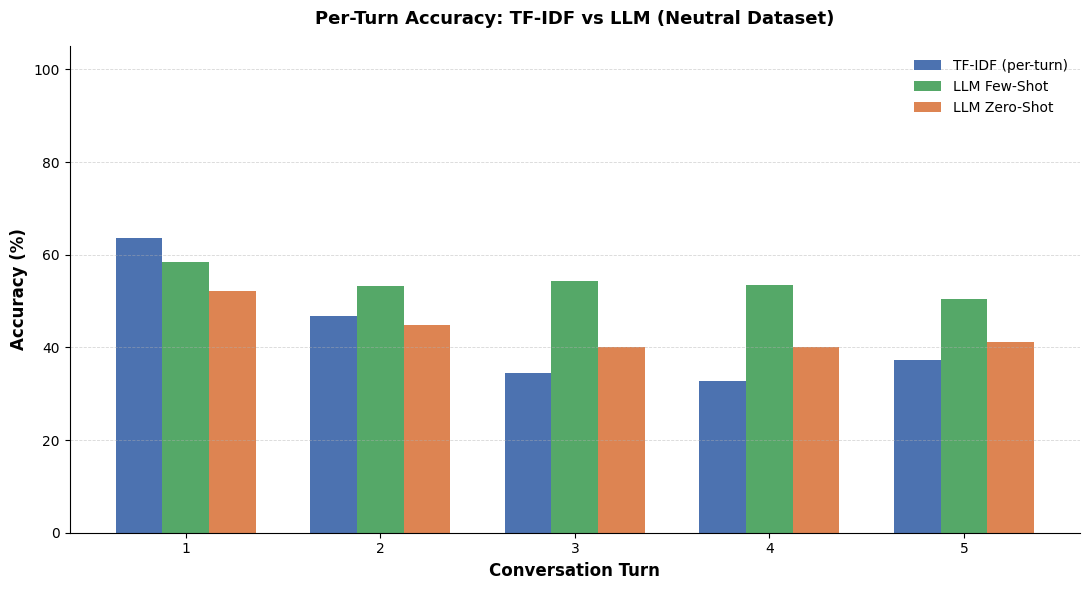


Per-turn accuracy comparison (percent):
 conversation_turn  tfidf_accuracy_pct  llm_fewshot_pct  llm_zeroshot_pct
                 1               63.55            58.45             52.11
                 2               46.73            53.29             44.84
                 3               34.58            54.23             40.14
                 4               32.71            53.52             40.14
                 5               37.38            50.47             41.08


In [40]:
# Per-turn TF-IDF models and grouped comparison with LLM few/zero-shot
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# Load dataset and compute TF-IDF accuracy per conversation turn
dataset_path = 'datasets/dataset_a_neutral.csv'
df = pd.read_csv(dataset_path)

turns = [0,1,2,3,4]
tfidf_accuracies = []

for t in turns:
    col = f'llm_output_{t}'
    if col not in df.columns:
        raise ValueError(f"Column {col} not found in {dataset_path}")

    texts = df[col].astype(str).tolist()
    labels = df['trait_selected'].astype(str).tolist()

    X_train, X_test, y_train, y_test = train_test_split(texts, labels, test_size=0.25, random_state=42)
    vec = TfidfVectorizer()
    X_train_tfidf = vec.fit_transform(X_train)
    X_test_tfidf = vec.transform(X_test)

    clf = LogisticRegression(max_iter=1000)
    clf.fit(X_train_tfidf, y_train)
    preds = clf.predict(X_test_tfidf)
    acc = accuracy_score(y_test, preds) * 100
    tfidf_accuracies.append(acc)

# Compute per-turn LLM few-shot and zero-shot accuracies from prediction CSVs
def per_turn_correct_pct_from_csv(path):
    d = pd.read_csv(path)
    if {'conversation_turn', 'label', 'prediction'}.difference(d.columns):
        raise ValueError(f"Missing required columns in {path}")
    gp = (
        d.assign(is_correct=(d['label'] == d['prediction']).astype(int))
         .groupby('conversation_turn', as_index=False)
         .agg(total=('is_correct','size'), correct=('is_correct','sum'))
         .sort_values('conversation_turn')
    )
    gp['correct_pct'] = (gp['correct'] / gp['total']) * 100
    return gp

few_path = 'predictions/dataset_a_neutral_few_shot_llm_observer.csv'
zero_path = 'predictions/dataset_a_neutral_zero_shot_llm_observer.csv'

few_gp = per_turn_correct_pct_from_csv(few_path)
zero_gp = per_turn_correct_pct_from_csv(zero_path)

# Align turns (convert to 1-based display if needed)
display_turns = few_gp['conversation_turn'].to_numpy()
tfidf_display_acc = np.array(tfidf_accuracies)[:len(display_turns)]
few_display_acc = few_gp['correct_pct'].to_numpy()
zero_display_acc = zero_gp['correct_pct'].to_numpy()

# Grouped bar chart: TF-IDF vs Few-shot vs Zero-shot
x = np.arange(len(display_turns))
width = 0.24

fig, ax = plt.subplots(figsize=(11,6))
# Colors: TF-IDF blue, Few-shot muted green, Zero-shot muted orange
ax.bar(x - width, tfidf_display_acc, width, label='TF-IDF (per-turn)', color='#4C72B0')
ax.bar(x, few_display_acc, width, label='LLM Few-Shot', color='#55A868')
ax.bar(x + width, zero_display_acc, width, label='LLM Zero-Shot', color='#DD8452')

ax.set_xlabel('Conversation Turn', fontsize=12, fontweight='bold')
ax.set_ylabel('Accuracy (%)', fontsize=12, fontweight='bold')
ax.set_title('Per-Turn Accuracy: TF-IDF vs LLM (Neutral Dataset)', fontsize=13, fontweight='bold', pad=16)
ax.set_xticks(x)
ax.set_xticklabels(display_turns)
ax.set_ylim(0, 105)
ax.grid(axis='y', linestyle='--', linewidth=0.6, alpha=0.5)
ax.legend(frameon=False)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

# Print table for quick inspection
summary_df = pd.DataFrame({
    'conversation_turn': display_turns,
    'tfidf_accuracy_pct': tfidf_display_acc.round(2),
    'llm_fewshot_pct': few_display_acc.round(2),
    'llm_zeroshot_pct': zero_display_acc.round(2)
})

print('\nPer-turn accuracy comparison (percent):')
print(summary_df.to_string(index=False))


In [41]:
# Export all analysis charts to disk (best quality)
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

out_dir = Path("analysis")
out_dir.mkdir(parents=True, exist_ok=True)


def save_fig(fig, name_stem):
    pdf_path = out_dir / f"{name_stem}.pdf"
    png_path = out_dir / f"{name_stem}.png"
    fig.savefig(pdf_path, bbox_inches="tight")
    fig.savefig(png_path, dpi=400, bbox_inches="tight")
    plt.close(fig)
    return str(pdf_path), str(png_path)

saved_files = []

# 1) TF-IDF neutral omission chart
tests = ["None", "Control", "Control/Middle"]
scores = [accuracy_all_neutral * 100, accuracy_noctrl_neutral * 100, accuracy_noctrl_middle_neutral * 100]
fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(tests, scores, color="#4C72B0")
ax.set_title("Accuracy scores of tf-idf with more neutral data")
ax.set_xlabel("Omission types")
ax.set_ylabel("Accuracy %")
ax.set_ylim(0, 100)
ax.grid(axis="y", linestyle="--", linewidth=0.6, alpha=0.5)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
saved_files.extend(save_fig(fig, "tfidf_neutral_omission_accuracy"))

# 2) TF-IDF biased omission chart
scores = [accuracy_all_bias * 100, accuracy_noctrl_bias * 100, accuracy_noctrl_middle_bias * 100]
fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(tests, scores, color="#DD8452")
ax.set_title("Accuracy scores of tf-idf with less neutral data")
ax.set_xlabel("Omission types")
ax.set_ylabel("Accuracy %")
ax.set_ylim(0, 100)
ax.grid(axis="y", linestyle="--", linewidth=0.6, alpha=0.5)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
saved_files.extend(save_fig(fig, "tfidf_biased_omission_accuracy"))

# 3) LLM overall shot comparison chart
fig, ax = plt.subplots(figsize=(7, 5))
ax.bar(["Zero Shot", "Few Shot"], [llm_accuracy_zshot, llm_accuracy_fshot], color="#55A868")
ax.set_title("Accuracy scores of llm observer with neutral data")
ax.set_xlabel("Shot types")
ax.set_ylabel("Accuracy %")
ax.set_ylim(0, 100)
ax.grid(axis="y", linestyle="--", linewidth=0.6, alpha=0.5)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
saved_files.extend(save_fig(fig, "llm_overall_shot_accuracy"))

# 4) Grouped bars: correct vs incorrect per turn (few-shot and zero-shot)
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
fig.suptitle("Prediction Correctness by Conversation Turn (Neutral Observer Datasets)", fontsize=13)

correct_color = "#4C72B0"
incorrect_color = "#DD8452"
for ax, stats, title in [
    (axes[0], few_stats, "Few-Shot Observer"),
    (axes[1], zero_stats, "Zero-Shot Observer"),
]:
    turns = stats["conversation_turn"].to_numpy()
    x = np.arange(len(turns))
    width = 0.38
    ax.bar(x - width / 2, stats["correct_pct"], width, label="Correct (%)", color=correct_color)
    ax.bar(x + width / 2, stats["incorrect_pct"], width, label="Incorrect (%)", color=incorrect_color)
    ax.set_title(title)
    ax.set_xlabel("Conversation Turn")
    ax.set_xticks(x)
    ax.set_xticklabels(turns)
    ax.set_ylim(0, 100)
    ax.grid(axis="y", linestyle="--", linewidth=0.6, alpha=0.5)
axes[0].set_ylabel("Percentage of Predictions (%)")
axes[0].legend(frameon=False)
saved_files.extend(save_fig(fig, "llm_per_turn_correct_incorrect_grouped"))

# 5) Line chart: few-shot vs zero-shot by turn
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(few_stats["conversation_turn"].values, few_stats["correct_pct"].values, marker="o", linewidth=2.5,
        markersize=8, label="Few-Shot Observer", color="#4C72B0")
ax.plot(zero_stats["conversation_turn"].values, zero_stats["correct_pct"].values, marker="s", linewidth=2.5,
        markersize=8, label="Zero-Shot Observer", color="#DD8452")
ax.set_xlabel("Conversation Turn", fontsize=12, fontweight="bold")
ax.set_ylabel("Accuracy (%)", fontsize=12, fontweight="bold")
ax.set_title("LLM Observer Accuracy by Conversation Turn (Neutral Dataset)", fontsize=13, fontweight="bold", pad=20)
ax.set_xticks(few_stats["conversation_turn"].values)
ax.set_ylim(0, 105)
ax.grid(True, linestyle="--", linewidth=0.6, alpha=0.5)
ax.legend(frameon=False, fontsize=11, loc="best")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
saved_files.extend(save_fig(fig, "llm_per_turn_accuracy_curve"))

# 6) Grouped bars: TF-IDF per-turn vs LLM few-shot vs LLM zero-shot
dataset_path = "datasets/dataset_a_neutral.csv"
df = pd.read_csv(dataset_path)

turns = [0, 1, 2, 3, 4]
tfidf_accuracies = []
for t in turns:
    col = f"llm_output_{t}"
    texts = df[col].astype(str).tolist()
    labels = df["trait_selected"].astype(str).tolist()
    X_train, X_test, y_train, y_test = train_test_split(texts, labels, test_size=0.25, random_state=42)
    vec = TfidfVectorizer()
    X_train_tfidf = vec.fit_transform(X_train)
    X_test_tfidf = vec.transform(X_test)
    clf = LogisticRegression(max_iter=1000)
    clf.fit(X_train_tfidf, y_train)
    preds = clf.predict(X_test_tfidf)
    tfidf_accuracies.append(accuracy_score(y_test, preds) * 100)

display_turns = few_stats["conversation_turn"].to_numpy()
tfidf_display_acc = np.array(tfidf_accuracies)[:len(display_turns)]
few_display_acc = few_stats["correct_pct"].to_numpy()
zero_display_acc = zero_stats["correct_pct"].to_numpy()

x = np.arange(len(display_turns))
width = 0.24
fig, ax = plt.subplots(figsize=(11, 6))
ax.bar(x - width, tfidf_display_acc, width, label="TF-IDF (per-turn)", color="#4C72B0")
ax.bar(x, few_display_acc, width, label="LLM Few-Shot", color="#55A868")
ax.bar(x + width, zero_display_acc, width, label="LLM Zero-Shot", color="#DD8452")
ax.set_xlabel("Conversation Turn", fontsize=12, fontweight="bold")
ax.set_ylabel("Accuracy (%)", fontsize=12, fontweight="bold")
ax.set_title("Per-Turn Accuracy: TF-IDF vs LLM (Neutral Dataset)", fontsize=13, fontweight="bold", pad=16)
ax.set_xticks(x)
ax.set_xticklabels(display_turns)
ax.set_ylim(0, 105)
ax.grid(axis="y", linestyle="--", linewidth=0.6, alpha=0.5)
ax.legend(frameon=False)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
saved_files.extend(save_fig(fig, "tfidf_vs_llm_per_turn_grouped"))

print("Saved chart files:")
for p in saved_files:
    print("-", p)

print("\nRecommended for best quality: PDF for papers/slides; PNG (400 dpi) for raster uses.")

Saved chart files:
- analysis/tfidf_neutral_omission_accuracy.pdf
- analysis/tfidf_neutral_omission_accuracy.png
- analysis/tfidf_biased_omission_accuracy.pdf
- analysis/tfidf_biased_omission_accuracy.png
- analysis/llm_overall_shot_accuracy.pdf
- analysis/llm_overall_shot_accuracy.png
- analysis/llm_per_turn_correct_incorrect_grouped.pdf
- analysis/llm_per_turn_correct_incorrect_grouped.png
- analysis/llm_per_turn_accuracy_curve.pdf
- analysis/llm_per_turn_accuracy_curve.png
- analysis/tfidf_vs_llm_per_turn_grouped.pdf
- analysis/tfidf_vs_llm_per_turn_grouped.png

Recommended for best quality: PDF for papers/slides; PNG (400 dpi) for raster uses.
